In [ ]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

In [ ]:
data = pd.read_csv("Titanic.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df = data.copy()
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna('S', inplace=True)
df.isnull().sum()
# df.head()

C:\Users\Hp\AppData\Local\Temp\ipykernel_19900\1084923877.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Hp\AppData\Local\Temp\ipykernel_19900\1084923877.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

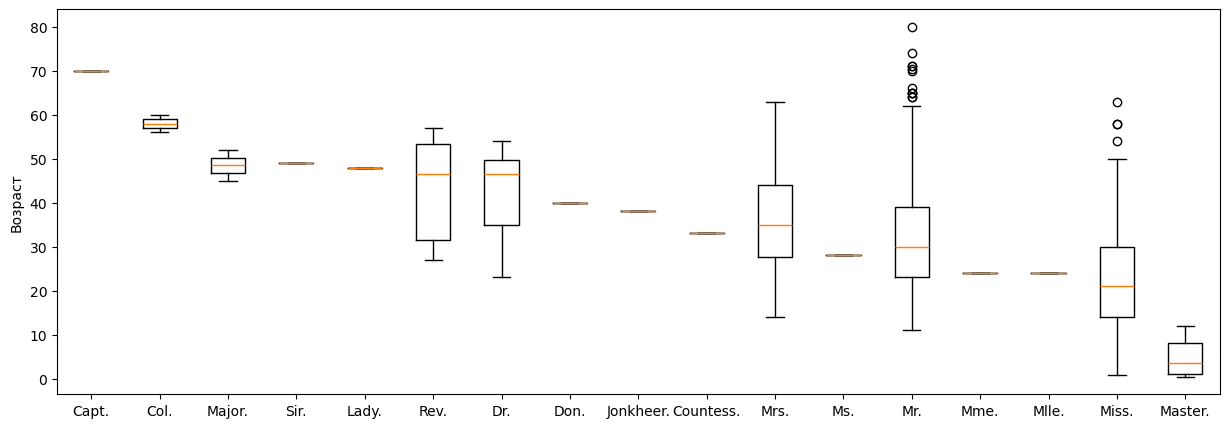

In [ ]:
titles = ("Capt.", "Col.", "Major.", "Sir.", "Lady.", "Rev.", "Dr.", "Don.", \
         "Jonkheer.", "Countess.", "Mrs.", "Ms.", "Mr.", "Mme.", "Mlle.", "Miss.", "Master.")

titled_names = []
for name in data.Name:
    for title in titles:
        if title in name.split(" "):
            titled_names.append(title)
            break

# data.insert(12, "Title", titled_names)

ages = dict.fromkeys(titles, [])
for i, title in enumerate(data.Title):
    if not pd.isna(data.Age[i]):
        ages[title] = ages[title] + [data.Age[i]]

fig, ax = plt.subplots(figsize=(15, 5))
ax.boxplot(ages.values(), tick_labels=titles, vert=True)
ax.set_ylabel("Возраст")
plt.show()

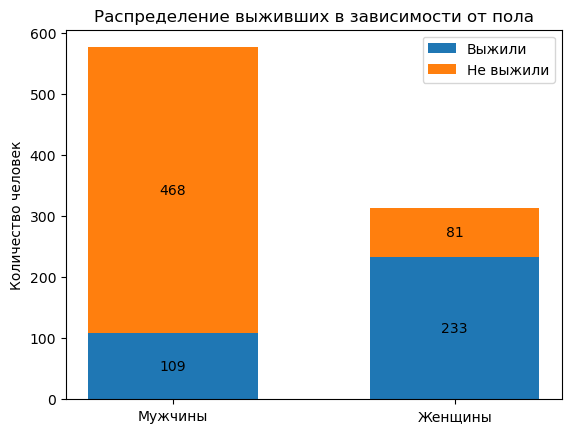

In [ ]:
male_count = len(data.loc[(data["Sex"] == "male")])
female_count = len(data.loc[(data["Sex"] == "female")])

survived_males = len(data.loc[(data["Sex"] == "male") & (data["Survived"] == 1)])
survived_females = len(data.loc[(data["Sex"] == "female") & (data["Survived"] == 1)])

survivors_count = {
    "Выжили": [survived_males, survived_females],
    "Не выжили": [male_count - survived_males, female_count - survived_females]
}

fig, ax = plt.subplots()
bottom = np.zeros(2)

for key, count in survivors_count.items():
    p = ax.bar(("Мужчины", "Женщины"), count, width=0.6, label=key, bottom=bottom)
    bottom += count
    ax.bar_label(p, label_type="center")

ax.set_title("Распределение выживших в зависимости от пола")
ax.set_ylabel("Количество человек")
ax.legend()
plt.show()

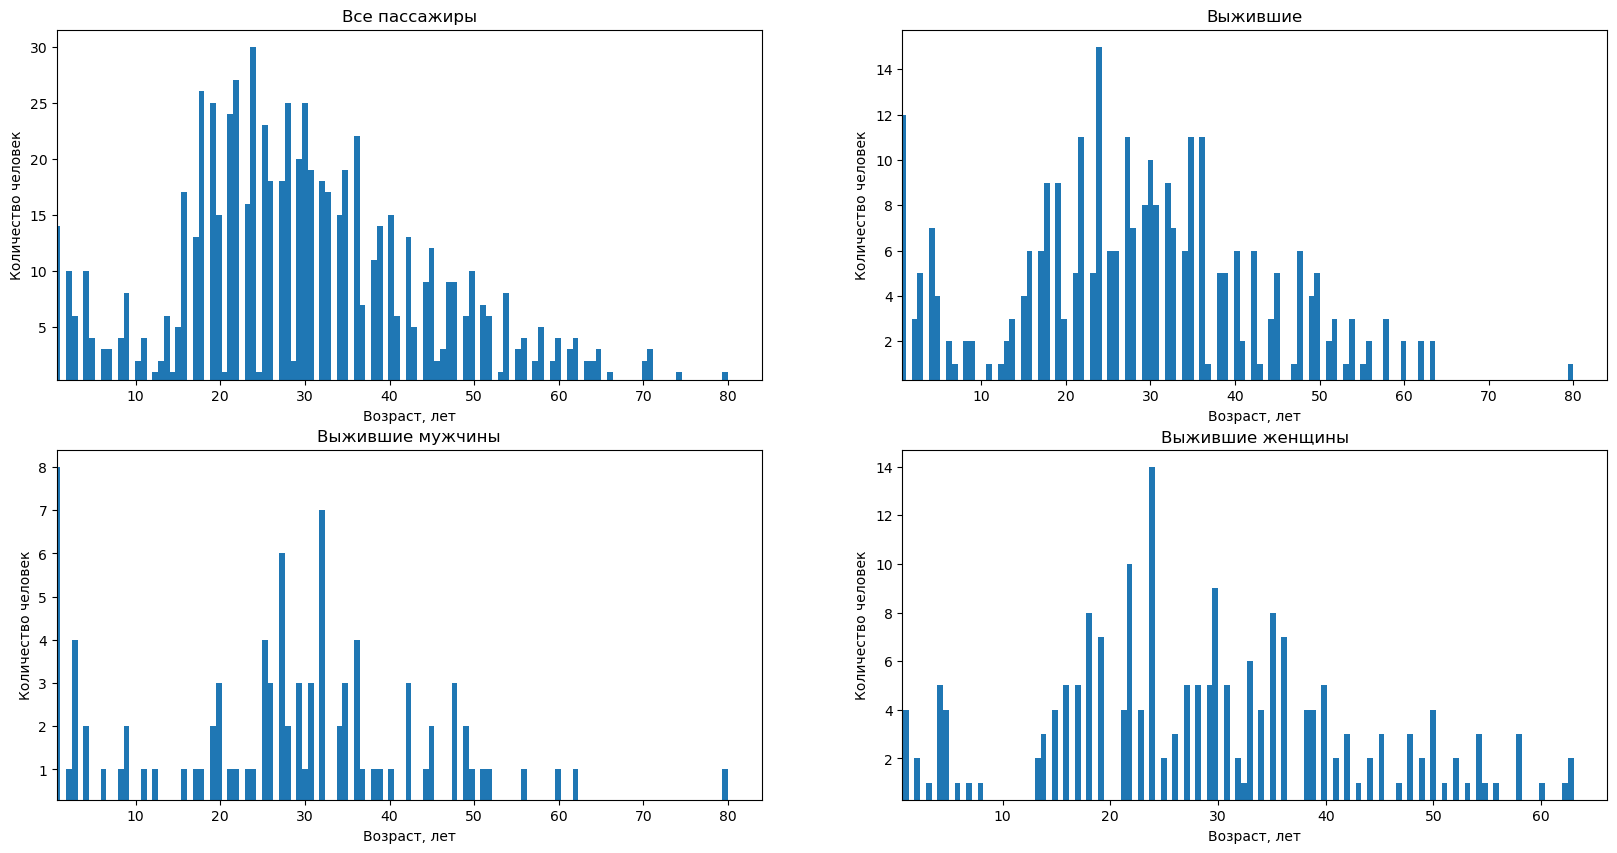

In [ ]:
from collections import Counter

survivors = data.loc[(data["Survived"] == 1)]

# male_count = len(data.loc[(data["Sex"] == "male")])
# female_count = len(data.loc[(data["Sex"] == "female")])

survived_males = data.loc[(data["Sex"] == "male") & (data["Survived"] == 1)]
survived_females = data.loc[(data["Sex"] == "female") & (data["Survived"] == 1)]

ages_num = len(dict(Counter(survivors["Age"])).keys())

fig, axs = plt.subplots(2, 2)
fig.set_figwidth(20)
fig.set_figheight(10)
names = [["Все пассажиры", "Выжившие"], ["Выжившие мужчины", "Выжившие женщины"]]

for i, surv in enumerate([[data, survivors], [survived_males, survived_females]]):
    for j, subserv in enumerate(surv):
        axs[i][j].hist(subserv["Age"], bins=ages_num)
        axs[i][j].set_title(names[i][j])
        axs[i][j].set_xlabel("Возраст, лет")
        axs[i][j].set_ylabel("Количество человек")
        axs[i][j].set_xlim(0.7)
        axs[i][j].set_ylim(0.3)

plt.show()

In [ ]:
import numpy as np

children = data.loc[((data["Age"] > 0) & (data["Age"] < np.float64(18.0)))]
survivors_children = data.loc[((data["Age"] < np.float64(18.0)) & (data["Age"] > 0) & (data["Survived"] == 1))]
print(f"Пассажиров до 18 лет спаслось: {round(len(survivors_children) * 100 / len(children), 2)}%")

Пассажиров до 18 лет спаслось: 53.98%


In [ ]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
Title            0
dtype: int64

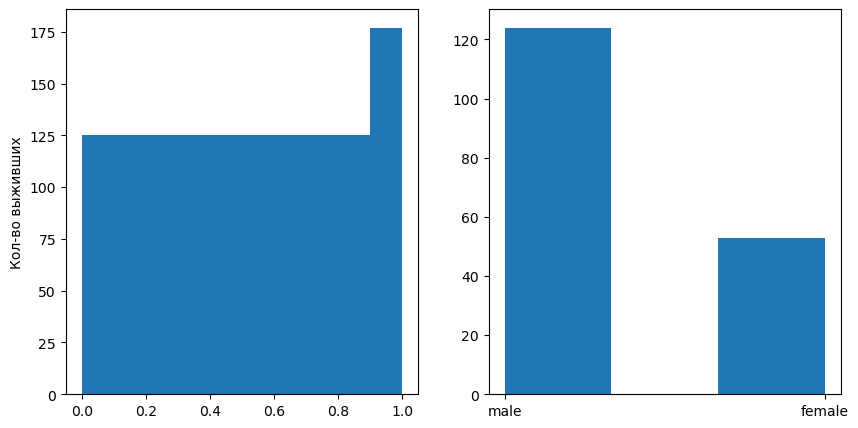

In [ ]:
noage = data.loc[(pd.isna(data["Age"]))]
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(noage.Survived, bins=10, cumulative=1)
ax[1].hist(noage.Sex, bins=3)
ax[0].set_ylabel("Кол-во выживших")
plt.show()

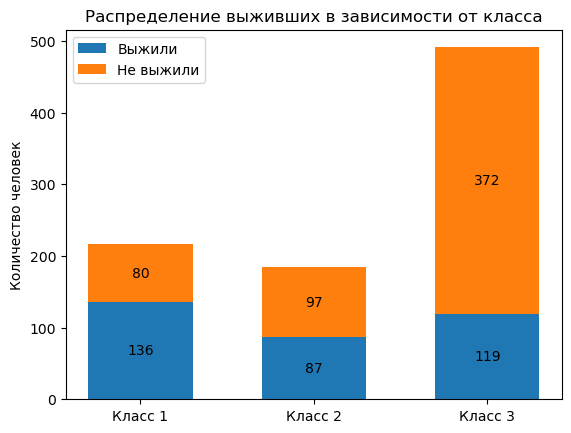

In [ ]:
from matplotlib.ticker import MaxNLocator


first_class = len(data.loc[(data["Pclass"] == 1)])
second_class = len(data.loc[(data["Pclass"] == 2)])
third_class = len(data.loc[(data["Pclass"] == 3)])

first_class_surv = len(data.loc[(data["Pclass"] == 1) & (data["Survived"] == 1)])
second_class_surv = len(data.loc[(data["Pclass"] == 2) & (data["Survived"] == 1)])
third_class_surv = len(data.loc[(data["Pclass"] == 3) & (data["Survived"] == 1)])

survivors_count = {
    "Выжили": [first_class_surv, second_class_surv, third_class_surv],
    "Не выжили": [first_class - first_class_surv, second_class - second_class_surv, third_class - third_class_surv]
}



dig, ax = plt.subplots()
bottom = np.zeros(3)

for key, value in survivors_count.items():
    p = ax.bar(("Класс 1", "Класс 2", "Класс 3"), value, width=0.6, label=key, bottom=bottom)
    bottom += value
    ax.bar_label(p, label_type="center")

ax.set_title("Распределение выживших в зависимости от класса")
ax.set_ylabel("Количество человек")
ax.legend()
plt.show()


plt.show()

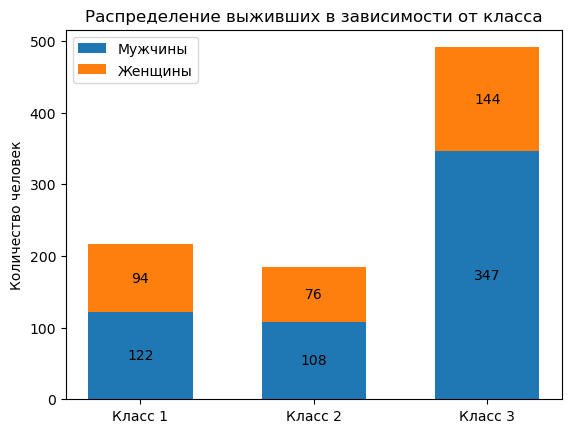

In [ ]:
from matplotlib.ticker import MaxNLocator


first_class_female = len(data.loc[(data["Pclass"] == 1) & (data["Sex"] == "female")])
second_class_female = len(data.loc[(data["Pclass"] == 2) & (data["Sex"] == "female")])
third_class_female = len(data.loc[(data["Pclass"] == 3) & (data["Sex"] == "female")])

first_class_male = len(data.loc[(data["Pclass"] == 1) & (data["Sex"] == "male")])
second_class_male = len(data.loc[(data["Pclass"] == 2) & (data["Sex"] == "male")])
third_class_male = len(data.loc[(data["Pclass"] == 3) & (data["Sex"] == "male")])

survivors_count = {
    "Мужчины": [first_class_male, second_class_male, third_class_male],
    "Женщины": [first_class_female, second_class_female, third_class_female]
}



dig, ax = plt.subplots()
bottom = np.zeros(3)

for key, value in survivors_count.items():
    p = ax.bar(("Класс 1", "Класс 2", "Класс 3"), value, width=0.6, label=key, bottom=bottom)
    bottom += value
    ax.bar_label(p, label_type="center")

ax.set_title("Распределение выживших в зависимости от класса")
ax.set_ylabel("Количество человек")
ax.legend()
plt.show()

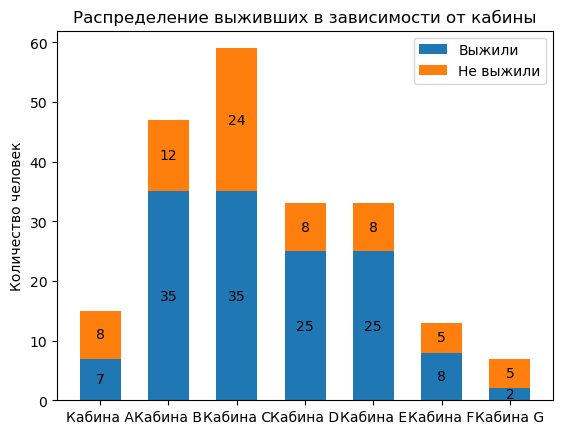

In [ ]:
cabin_a = len(data.loc[data["Cabin"].str.contains("A", na=False)])
cabin_b = len(data.loc[data["Cabin"].str.contains("B", na=False)])
cabin_c = len(data.loc[data["Cabin"].str.contains("C", na=False)])
cabin_d = len(data.loc[data["Cabin"].str.contains("D", na=False)])
cabin_e = len(data.loc[data["Cabin"].str.contains("E", na=False)])
cabin_f = len(data.loc[data["Cabin"].str.contains("F", na=False)])
cabin_g = len(data.loc[data["Cabin"].str.contains("G", na=False)])

cabin_a_survived = len(data.loc[(data["Cabin"].str.contains("A", na=False)) & (data["Survived"] == 1)])
cabin_b_survived = len(data.loc[(data["Cabin"].str.contains("B", na=False)) & (data["Survived"] == 1)])
cabin_c_survived = len(data.loc[(data["Cabin"].str.contains("C", na=False)) & (data["Survived"] == 1)])
cabin_d_survived = len(data.loc[(data["Cabin"].str.contains("D", na=False)) & (data["Survived"] == 1)])
cabin_e_survived = len(data.loc[(data["Cabin"].str.contains("E", na=False)) & (data["Survived"] == 1)])
cabin_f_survived = len(data.loc[(data["Cabin"].str.contains("F", na=False)) & (data["Survived"] == 1)])
cabin_g_survived = len(data.loc[(data["Cabin"].str.contains("G", na=False)) & (data["Survived"] == 1)])

survivors_count = {
    "Выжили": [cabin_a_survived, cabin_b_survived, cabin_c_survived, cabin_d_survived, \
               cabin_e_survived, cabin_f_survived, cabin_g_survived],
    "Не выжили": [cabin_a - cabin_a_survived, cabin_b - cabin_b_survived, \
                  cabin_c - cabin_c_survived, cabin_d - cabin_d_survived, \
                  cabin_e - cabin_e_survived, cabin_f - cabin_f_survived, \
                  cabin_g - cabin_g_survived]
}

dig, ax = plt.subplots()
bottom = np.zeros(7)

for key, value in survivors_count.items():
    p = ax.bar(("Кабина A", "Кабина B", "Кабина C", "Кабина D", "Кабина E", "Кабина F", "Кабина G"), \
              value, width=0.6, label=key, bottom=bottom)
    bottom += value
    ax.bar_label(p, label_type="center")

ax.set_title("Распределение выживших в зависимости от кабины")
ax.set_ylabel("Количество человек")
ax.legend()
plt.show()



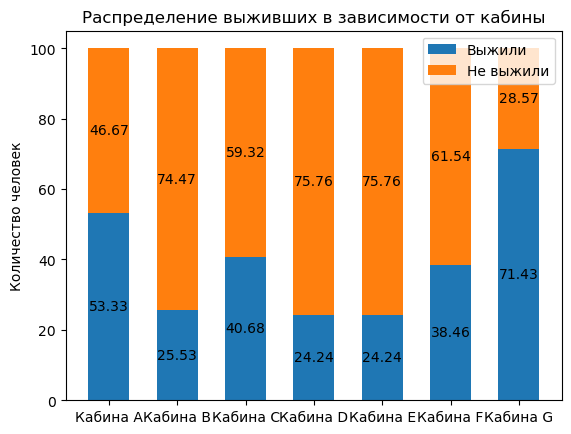

In [ ]:
cabin_a = len(data.loc[data["Cabin"].str.contains("A", na=False)])
cabin_b = len(data.loc[data["Cabin"].str.contains("B", na=False)])
cabin_c = len(data.loc[data["Cabin"].str.contains("C", na=False)])
cabin_d = len(data.loc[data["Cabin"].str.contains("D", na=False)])
cabin_e = len(data.loc[data["Cabin"].str.contains("E", na=False)])
cabin_f = len(data.loc[data["Cabin"].str.contains("F", na=False)])
cabin_g = len(data.loc[data["Cabin"].str.contains("G", na=False)])

cabin_a_survived = len(data.loc[(data["Cabin"].str.contains("A", na=False)) & (data["Survived"] == 1)])
cabin_b_survived = len(data.loc[(data["Cabin"].str.contains("B", na=False)) & (data["Survived"] == 1)])
cabin_c_survived = len(data.loc[(data["Cabin"].str.contains("C", na=False)) & (data["Survived"] == 1)])
cabin_d_survived = len(data.loc[(data["Cabin"].str.contains("D", na=False)) & (data["Survived"] == 1)])
cabin_e_survived = len(data.loc[(data["Cabin"].str.contains("E", na=False)) & (data["Survived"] == 1)])
cabin_f_survived = len(data.loc[(data["Cabin"].str.contains("F", na=False)) & (data["Survived"] == 1)])
cabin_g_survived = len(data.loc[(data["Cabin"].str.contains("G", na=False)) & (data["Survived"] == 1)])

survivors_count = {
    "Выжили": [100 - round((cabin_a_survived * 100) / cabin_a, 2), 100 - round((cabin_b_survived * 100) / cabin_b, 2), 100 - round((cabin_c_survived * 100) / cabin_c, 2), 100 - round((cabin_d_survived * 100) / cabin_d, 2), \
               100 - round((cabin_e_survived * 100) / cabin_e, 2), 100 - round((cabin_f_survived * 100) / cabin_f, 2), 100 - round((cabin_g_survived * 100) / cabin_g, 2)],
    "Не выжили": [round((cabin_a_survived * 100) / cabin_a, 2), round((cabin_b_survived * 100) / cabin_b, 2), \
                  round((cabin_c_survived * 100) / cabin_c, 2), round((cabin_d_survived * 100) / cabin_d, 2), \
                  round((cabin_e_survived * 100) / cabin_e, 2), round((cabin_f_survived * 100) / cabin_f, 2), \
                  round((cabin_g_survived * 100) / cabin_g, 2)]
}


dig, ax = plt.subplots()
bottom = np.zeros(7)

for key, value in survivors_count.items():
    p = ax.bar(("Кабина A", "Кабина B", "Кабина C", "Кабина D", "Кабина E", "Кабина F", "Кабина G"), \
              value, width=0.6, label=key, bottom=bottom)
    bottom += value
    ax.bar_label(p, label_type="center")

ax.set_title("Распределение выживших в зависимости от кабины")
ax.set_ylabel("Количество человек")
ax.legend()
plt.show()



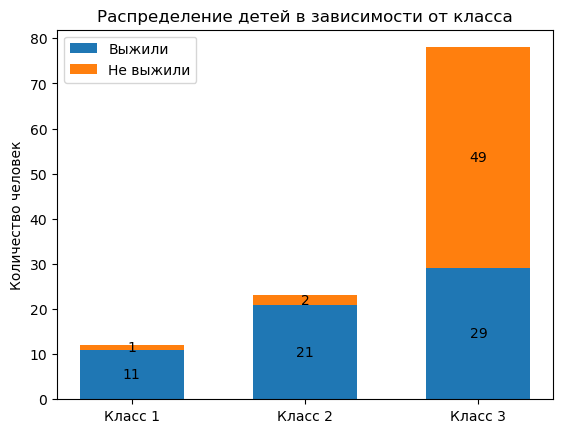

In [ ]:
# children = data.loc[(data["Age"] <= 18) & (data["Age"] < np.float64(18.0))]
# children_surv = data.loc[(data["Age"] <= 18) & (data["Age"] < np.float64(18.0)) & (data["Survived"] == 1)]


first_class_ch = len(data.loc[(data["Pclass"] == 1) & (data["Age"] <= 18) & (data["Age"] < np.float64(18.0))])
second_class_ch = len(data.loc[(data["Pclass"] == 2) & (data["Age"] <= 18) & (data["Age"] < np.float64(18.0))])
third_class_ch = len(data.loc[(data["Pclass"] == 3) & (data["Age"] <= 18) & (data["Age"] < np.float64(18.0))])

first_class_ch_surv = len(data.loc[(data["Pclass"] == 1) & (data["Age"] <= 18) & (data["Age"] < np.float64(18.0)) & (data["Survived"] == 1)])
second_class_ch_surv = len(data.loc[(data["Pclass"] == 2) & (data["Age"] <= 18) & (data["Age"] < np.float64(18.0)) & (data["Survived"] == 1)])
third_class_ch_surv = len(data.loc[(data["Pclass"] == 3) & (data["Age"] <= 18) & (data["Age"] < np.float64(18.0)) & (data["Survived"] == 1)])

survivors_count = {
    "Выжили": [first_class_ch_surv, second_class_ch_surv, third_class_ch_surv],
    "Не выжили": [first_class_ch - first_class_ch_surv, second_class_ch - second_class_ch_surv, third_class_ch - third_class_ch_surv]
}



dig, ax = plt.subplots()
bottom = np.zeros(3)

for key, value in survivors_count.items():
    p = ax.bar(("Класс 1", "Класс 2", "Класс 3"), value, width=0.6, label=key, bottom=bottom)
    bottom += value
    ax.bar_label(p, label_type="center")

ax.set_title("Распределение детей в зависимости от класса")
ax.set_ylabel("Количество человек")
ax.legend()
plt.show()